# Imports

In [1]:
%reload_ext autoreload
%autoreload 2


import os
import sys
import imagehash
from PIL import Image
from tqdm import tqdm
import pickle
import matplotlib
import numpy as np
import PIL
import torch
from IPython.display import display
from PIL import Image
from torchvision.utils import draw_segmentation_masks

from ftdinosaur_inference import build_dinosaur, utils


# local imports
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), "src"))
from densifier.submodules.dino_ft_wrapper import (
    load_model,
    get_masks_as_image,
    overlay_masks_on_image,
    prep_for_display,
    get_cmap
)
from densifier.get_segments.run_cropformer import EntitySegDecoder
sys.path.pop(0)


CONF_THRESHOLD = 0.5


/mnt/lustre/work/oh/arubinstein17/github/densification/envs/seg_env/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/mnt/lustre/work/oh/arubinstein17/github/densification/envs/seg_env/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Using PyTorch large kernel dw conv impl


# Functions

In [2]:
# show images with masks overlayed
def show_cropformer_mask_overlay(image_tensor, output_mask, alpha=0.6):

    num_masks = int(output_mask.max()) + 1
    masks_as_image = torch.zeros((num_masks, output_mask.shape[0], output_mask.shape[1])).to(torch.bool)
    for mask_value in range(num_masks):
        masks_as_image[mask_value] = torch.Tensor(output_mask == mask_value)

    assert len(image_tensor.shape) == 4
    masks_on_image = draw_segmentation_masks(
        image_tensor[0].permute(2, 0, 1), masks_as_image, alpha=alpha, colors=get_cmap(num_masks)
    )

    # Convert back to PIL
    masks_on_image = masks_on_image.permute(1, 2, 0).numpy()
    image_to_show = Image.fromarray(masks_on_image.astype(np.uint8))
    return image_to_show


def show_cropformer_mask_overlay_from_path_list(model, path_list, alpha=0.6):
    model.eval()
    for path in path_list:
        print(path)
        image = Image.open(path).convert("RGB")
        image_tensor = torch.tensor(np.array(image).astype(np.uint8)).unsqueeze(0)
        output_mask = model(image_tensor)
        image_to_show = show_cropformer_mask_overlay(image_tensor, output_mask, alpha=alpha)
        display(image_to_show)


# find similar images
def get_dataset_stats(dataset_path):
    path2label = make_path2label_counter_animal(dataset_path)
    print_classwise_stats(path2label)
    # Compute hashes for each image
    hashes = compute_hashes(path2label)

    # Count near-duplicates
    near_duplicates = count_near_duplicates(hashes, threshold=0)
    print_duplicates_stats(near_duplicates)


def compute_hashes(path_label_pairs, hash_func=imagehash.phash):
    # Compute hashes for each image
    hashes = []
    for path, _ in tqdm(path_label_pairs):
        try:
            img = Image.open(path)
            # img_hash = imagehash.average_hash(img)  # Choose a hash method, e.g., average hash
            img_hash = hash_func(img)  # Choose a hash method, e.g., average hash
            hashes.append((path, img_hash))
        except Exception as e:
            print(f"Error processing {path}: {e}")
    return hashes


def count_near_duplicates(hashes, threshold=5, verbose=False):
    # duplicates = 0
    num_hashes = len(hashes)
    duplicates = {path: [path] for path, hash in hashes}

    for i in tqdm(range(num_hashes)):
        path_i, hash_i = hashes[i]
        if path_i not in duplicates:
            continue
        for j in range(i + 1, num_hashes):
            # Compute the Hamming distance between hashes

            path_j, hash_j = hashes[j]

            if hash_i - hash_j <= threshold:
            # if hash_i == hash_j:
                # duplicates += 1
                class_i = path_i.split(os.sep)[-2]
                class_j = path_j.split(os.sep)[-2]
                assert class_i == class_j, f"{class_i} != {class_j} for {path_i} and {path_j}"
                duplicates[path_i].append(path_j)
                if verbose:
                    print(f"removing {j}-th {path_j} because it is similar to {i}-th {path_i}")
                duplicates.pop(path_j)

    return duplicates

# Find similar

In [ ]:
images_from_dino_ft_paper_path = "/home/oh/arubinstein17/github/densification/notebooks/images_from_dino"
movi_e_per_image_path = "/mnt/lustre/work/oh/arubinstein17/cache/movi/movi_e_per_image/"
path_label_pairs = [(os.path.join(movi_e_per_image_path, path), None) for path in os.listdir(movi_e_per_image_path) if path.endswith(".png")]
hashes = compute_hashes(path_label_pairs)


In [ ]:

threshold = 0
hash_func = imagehash.phash
for img_path in os.listdir(images_from_dino_ft_paper_path):

    img = Image.open(os.path.join(images_from_dino_ft_paper_path, img_path))
    img_hash = hash_func(img)

    for path, hash_for_path in hashes:
        if hash_for_path - img_hash <= threshold:
            print(f"similar {img_path} and {path}")


# Predict with CropFormer-EntitySeg

In [5]:
# CONFIG_FILE =
# OPTS =


# class EntitySegDecoder(torch.nn.Module):
#     def __init__(
#         self,
#         # checkpoint_path: str,
#         config_path: str,
#         opts: List[str],
#         confidence_threshold: float
#     )

model = EntitySegDecoder(
    config_path="/home/oh/arubinstein17/github/densification/src/densifier/get_segments/cropformer_hornet.yaml",
    opts=["MODEL.WEIGHTS", "/home/oh/arubinstein17/github/densification/models/CropFormer_hornet_3x/CropFormer_model/Entity_Segmentation/CropFormer_hornet_3x/CropFormer_hornet_3x_03823a.pth"],
    confidence_threshold=CONF_THRESHOLD
)


[GConvNet]: convert str gconv to func
[gconv] 2 order with dims= [96, 192] scale=0.3333
[gconv] 2 order with dims= [96, 192] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 3 order with dims= [96, 192, 384] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 384, 768] scale=0.3333
[gconv] 4 order with dims= [96, 192, 

### Bears example

In [10]:
bears_path = "/home/oh/arubinstein17/github/densification/notebooks/polar_bears.png"

In [3]:

image = Image.open(bears_path).convert("RGB")

In [6]:
image_tensor = torch.tensor(np.array(image).astype(np.uint8)).unsqueeze(0)
model.eval()
output_mask = model(image_tensor)

/mnt/lustre/work/oh/arubinstein17/github/densification/envs/seg_env/lib/python3.10/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


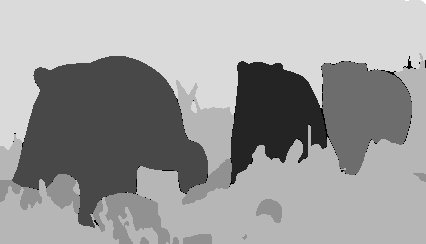

In [7]:
display(prep_for_display(torch.tensor(output_mask)))

/home/oh/arubinstein17/github/densification/notebooks/polar_bears.png


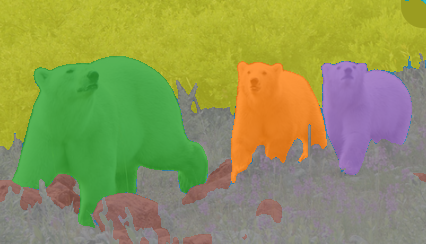

In [13]:
show_cropformer_mask_overlay_from_path_list(model, [bears_path], alpha=0.8)

torch.Size([1, 244, 426, 3])
torch.Size([1, 244, 426, 1])
torch.Size([1, 244, 426, 3])


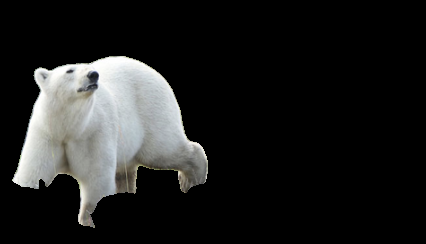

In [33]:
mask_tensor = torch.tensor(output_mask==2).unsqueeze(0).unsqueeze(3)
# image_tensor_permuted = image_tensor.permute(0, 3, 1, 2).numpy()
print(image_tensor.shape)
print(mask_tensor.shape)
# result = image_tensor * mask_tensor + (1-mask_tensor) * torch.ones_like(image_tensor)
result = image_tensor * mask_tensor
print(result.shape)
result = result.squeeze(0).numpy()
result = Image.fromarray(result.astype(np.uint8))
display(result)
# print(mask_tensor.shape)
# print(image_tensor_permuted.shape)
# display(prep_for_display())

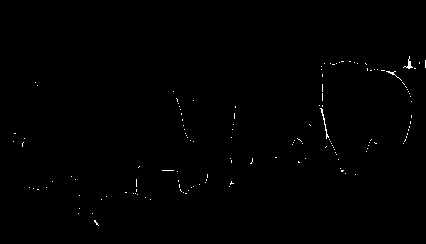

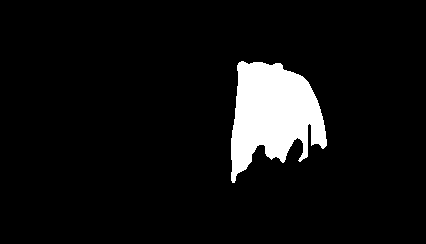

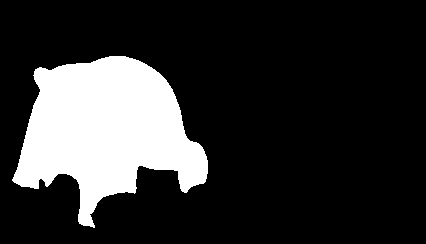

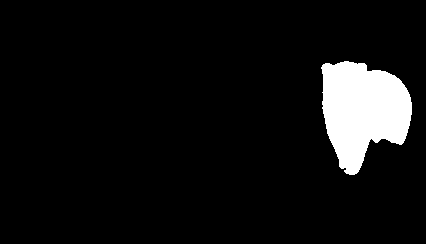

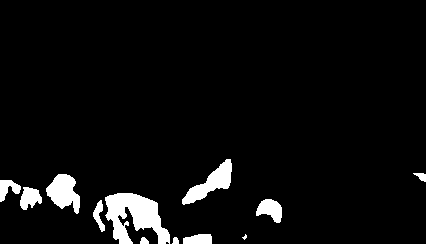

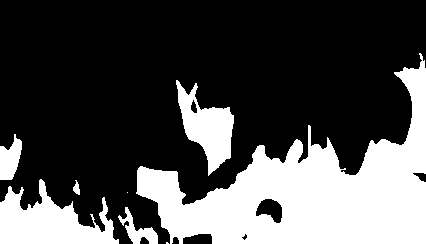

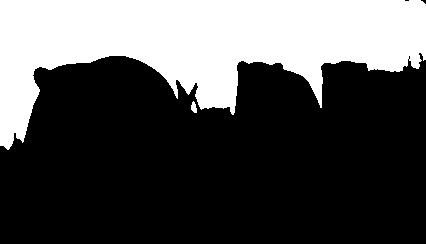

In [15]:
display(prep_for_display(torch.tensor(output_mask==0)))
display(prep_for_display(torch.tensor(output_mask==1)))
display(prep_for_display(torch.tensor(output_mask==2)))
display(prep_for_display(torch.tensor(output_mask==3)))
display(prep_for_display(torch.tensor(output_mask==4)))
display(prep_for_display(torch.tensor(output_mask==5)))
display(prep_for_display(torch.tensor(output_mask==6)))

### Old example

In [4]:
image = Image.open("/home/oh/arubinstein17/github/densification/src/densifier/submodules/dino_ft/notebooks/images/example.jpg").convert("RGB")

In [5]:
image_tensor = torch.tensor(np.array(image).astype(np.uint8)).unsqueeze(0)

In [ ]:
print(image_tensor.shape)

In [ ]:
print(image_tensor.dtype)

In [ ]:
model.eval()
output_mask = model(image_tensor)


In [ ]:
# output_mask = torch.tensor(output_mask.squeeze(0)).permute(1, 2, 0)

In [ ]:
print(output_mask.shape)

In [ ]:
display(prep_for_display(torch.tensor(output_mask)))

## main

In [ ]:
path_list = [
    "/home/oh/arubinstein17/github/densification/src/densifier/submodules/dino_ft/notebooks/images/example.jpg",
    # "/home/oh/arubinstein17/github/densification/src/densifier/submodules/dino_ft/notebooks/images/example.jpg"
    "/home/oh/arubinstein17/github/densification/notebooks/images_from_dino/011.jpg",
    "/home/oh/arubinstein17/github/densification/notebooks/images_from_dino/046.jpg",
    "/home/oh/arubinstein17/github/densification/notebooks/images_from_dino/055.jpg",
    "/home/oh/arubinstein17/github/densification/notebooks/images_from_dino/086.jpg",
]
model = EntitySegDecoder(
    config_path="/home/oh/arubinstein17/github/densification/src/densifier/get_segments/cropformer_hornet.yaml",
    opts=["MODEL.WEIGHTS", "/home/oh/arubinstein17/github/densification/models/CropFormer_hornet_3x/CropFormer_model/Entity_Segmentation/CropFormer_hornet_3x/CropFormer_hornet_3x_03823a.pth"],
    confidence_threshold=CONF_THRESHOLD
)


In [ ]:
show_cropformer_mask_overlay_from_path_list(model, path_list, alpha=0.6)

# Predict with Dino-FT

In [50]:
model_name = "dinosaur_base_patch14_518_topk3.coco_dv2_ft_s7_300k+10k"
model = load_model(model_name)
preproc = build_dinosaur.build_preprocessing(model_name)

In [ ]:
# image = Image.open("./images/example.jpg").convert("RGB")
image = Image.open("/home/oh/arubinstein17/github/densification/src/densifier/submodules/dino_ft/notebooks/images/example.jpg").convert("RGB")
display(image)

In [52]:
with torch.no_grad():
    inp = preproc(image).unsqueeze(0)
    outp = model(inp, num_slots=5)

In [ ]:
masks_with_image = overlay_masks_on_image(
    image, outp["masks"], num_masks=outp["masks"].shape[1]
)
display(masks_with_image)

In [ ]:
img = image
masks = outp["masks"]
num_masks = masks.shape[1]
alpha = 0.6

img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1)  # C x H x W
height, width = img_tensor.shape[1:]

# Need to resize masks to image (1 x K x P -> 1 x K x H x W)
masks_as_image = utils.resize_patches_to_image(masks, size=(height, width))
masks_as_image = utils.soft_masks_to_one_hot(masks_as_image).squeeze(0)

print(masks_as_image.shape)
print(masks_as_image.dtype)
print(type(masks_as_image))
# Overlay masks on image
masks_on_image = draw_segmentation_masks(
    img_tensor, masks_as_image, alpha=alpha, colors=get_cmap(num_masks)
)

# Convert back to PIL
masks_on_image = masks_on_image.permute(1, 2, 0).numpy()
res = Image.fromarray(masks_on_image.astype(np.uint8))
display(res)

In [ ]:
outp["masks"].shape


In [ ]:
masks_as_image = get_masks_as_image(
    outp["masks"],
    height=image.height,
    width=image.width
)

In [ ]:
display(prep_for_display(masks_as_image))

In [8]:
masks_example = pickle.load(open("/home/oh/arubinstein17/github/densification/data/masks/UrbanCars_test_masks.pkl", "rb"))

In [ ]:
m = masks_example["mnt/lustre/work/oh/arubinstein17/cache/UrbanCars/test/0/000.jpg"]["mask"]
print(m.shape)
print(type(m))
print(m.dtype)
